# Rossler system solved with Tsit5

This notebook solves the three-dimensional Rossler system using `Tsit5()`, a high-quality adaptive Runge-Kutta method from the Julia SciML ecosystem. It produces a three-dimensional phase-space trajectory and time histories for all three state variables.

The governing equations are

$$\dot{x}=-y-z,\qquad \dot{y}=x+a y,\qquad \dot{z}=b+z(x-c).$$

Change `a`, `b`, and `c` in the parameter cell below, then rerun the remaining cells. The defaults are a commonly used chaotic parameter set.

## One-time package setup

If `DifferentialEquations` and `Plots` are not already installed in the active Julia environment, remove the comment markers from the next cell and run it once. `DifferentialEquations` supplies the Tsit5 solver as part of the much larger `DifferentialEquations` meta-package. After installation, leave the cell commented to avoid repeated package operations.  The first intall may take a while!

In [1]:
#using Pkg
#Pkg.add(["DifferentialEquations", "Plots"])

    Updating registry at `C:\Users\AllanStruthers\.julia\registries\General.toml`
   Resolving package versions...
   Installed IntelOpenMP_jll ────────────────── v2025.2.0+0
   Installed OrdinaryDiffEqSDIRK ────────────── v2.9.2
   Installed OrdinaryDiffEqRosenbrock ───────── v2.7.1
   Installed FiniteDiff ─────────────────────── v2.33.0
   Installed OrdinaryDiffEqVerner ───────────── v2.4.1
   Installed AMD ────────────────────────────── v0.5.3
   Installed DifferentialEquations ──────────── v8.1.1
   Installed NonlinearSolve ─────────────────── v4.29.1
   Installed NonlinearSolveQuasiNewton ──────── v1.15.3
   Installed OrdinaryDiffEqNonlinearSolve ───── v2.9.4
   Installed SimpleNonlinearSolve ───────────── v2.14.1
   Installed LineSearch ─────────────────────── v0.1.16
   Installed SpecialFunctions ───────────────── v2.9.0
   Installed PureKLU ────────────────────────── v1.4.1
   Installed NonlinearSolveSpectralMethods ──── v1.8.1
   Installed CommonSubexpressions ───────────── v0

In [5]:
using DifferentialEquations
using Plots

# Use the GR backend for lightweight, static plots in most Julia installations.
gr()

Plots.GRBackend()

## Parameters and initial condition

The three model parameters are deliberately defined as separate named variables for easy experimentation. `u0` contains the initial values `[x(0), y(0), z(0)]`; `tspan` specifies the time interval to simulate. A fixed `saveat` interval makes the plotted samples evenly spaced while Tsit5 still chooses its own internal adaptive timesteps.

In [6]:
# Editable Rossler parameters
a = 0.2
b = 0.2
c = 5.7

# Initial state: [x(0), y(0), z(0)]
u0 = [1.0, 0.0, 0.0]
tspan = (0.0, 200.0)
save_interval = 0.05

# Parameters passed into the ODE solver
params = (a, b, c)

(0.2, 0.2, 5.7)

## Define and solve the ODE

The function uses the in-place SciML convention: it writes the derivatives into `du` rather than allocating a new vector at every evaluation. `Tsit5()` is explicitly selected as the solver. The tight tolerances provide accurate trajectories, particularly important for the sensitive dependence of chaotic dynamics.

In [9]:
function rossler!(du, u, p, t)
    a, b, c = p
    x, y, z = u

    du[1] = -y - z
    du[2] = x + a * y
    du[3] = b + z * (x - c)

    return nothing
end

prob = ODEProblem(rossler!, u0, tspan, params)

sol = solve(
    prob,
    Tsit5();
    abstol = 1e-9,
    reltol = 1e-9,
    saveat = save_interval,
);

# Phase-space trajectory

This three-dimensional curve shows the system trajectory in `(x, y, z)` state space. The first part of the simulation is retained so that the path from the initial condition is visible; increase `tspan` if you would like a longer view of the attractor.

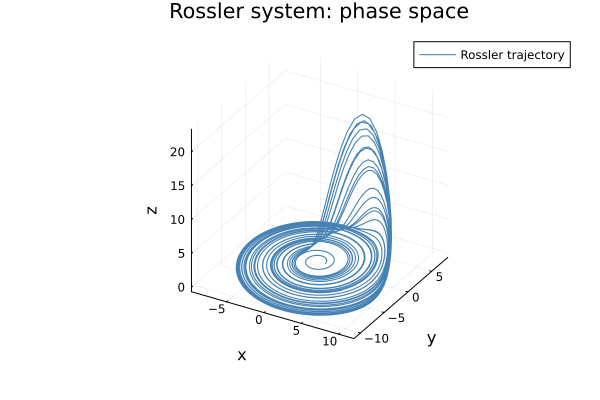

In [10]:
phase_plot = plot(
    sol[1, :], sol[2, :], sol[3, :];
    seriestype = :path3d,
    linewidth = 1.1,
    color = :steelblue,
    label = "Rossler trajectory",
    xlabel = "x",
    ylabel = "y",
    zlabel = "z",
    title = "Rossler system: phase space",
    legend = :topright,
)
display(phase_plot)

## Time histories

Each trace below is explicitly labelled in the legend. The shared time axis makes it easy to compare the evolution of the three scalar fields.

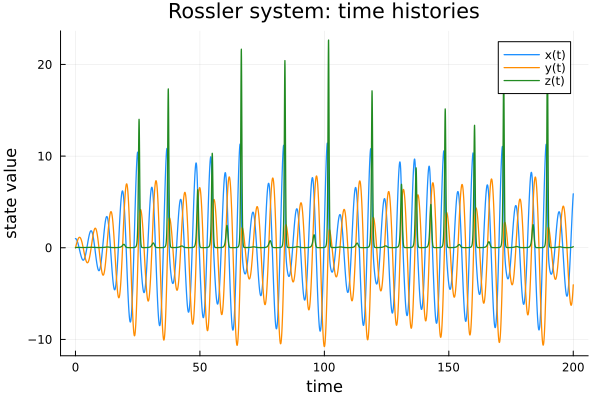

In [8]:
time_plot = plot(
    sol.t, sol[1, :];
    label = "x(t)",
    color = :dodgerblue,
    linewidth = 1.3,
    xlabel = "time",
    ylabel = "state value",
    title = "Rossler system: time histories",
    legend = :topright,
)
plot!(time_plot, sol.t, sol[2, :]; label = "y(t)", color = :darkorange, linewidth = 1.3)
plot!(time_plot, sol.t, sol[3, :]; label = "z(t)", color = :forestgreen, linewidth = 1.3)
display(time_plot)

### Notes for exploration

- Changing `c` has a pronounced effect on the attractor; try values near 4 to 6.
- Because the Rossler system can be chaotic, trajectories with slightly different initial conditions will eventually diverge.
- For a denser plotted curve, reduce `save_interval`; for a longer run, increase the end time in `tspan`.

    #Sensitivity